# **Aprendizaje no supervizado**

**K_Means**

El algoritmo de K-Means es uno de los más usados a la hora de aplicar Clustering, ya que es un método rápido y eficiente. Vamos a generar un conjunto de datos sintético para aprender a usar esta técnica.



Generamos un data sintetico



In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import random

n_centers = random.randint(1, 20)

blob_centers = []
while len(blob_centers) < n_centers:
    candidate = np.random.uniform(-10, 10, size=2)
    if all(np.linalg.norm(candidate - center) > 2 for center in blob_centers):
        blob_centers.append(candidate)

blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, 2.0)

from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)

print(f"Se generaron {n_centers}")

print("Coordenadas de los centroides:")
print(blob_centers)

Se generaron 4
Coordenadas de los centroides:
[[ 7.86383222 -2.42758916]
 [-6.24192081 -4.78903448]
 [ 5.36300807 -6.66497136]
 [-0.8605592  -4.70341137]]


* graficamos los centroides


In [16]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

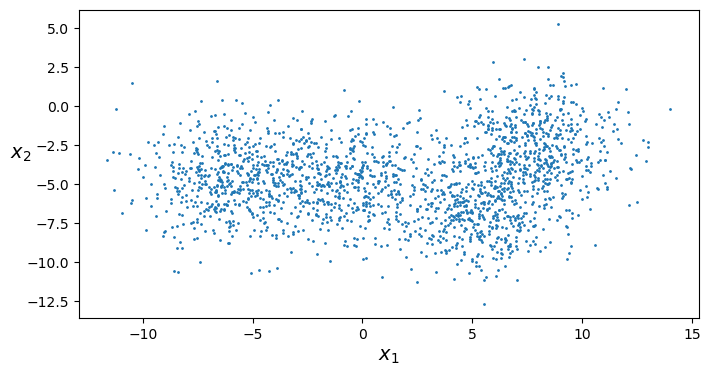

In [17]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

# **En Scikit-Learn puedes usar el objeto KMeans, indicando el número de clusters deseado.**

scikit-learn buscaremos comportmientos similares para poder agruparlos

etiqueta los datos a cada grupo de acuerdo a la cantidad que se almaceno en blob_centers

In [18]:
from sklearn.cluster import KMeans
k = len(blob_centers)
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred

array([1, 1, 0, ..., 1, 3, 0], shape=(2000,), dtype=int32)

Mostramos lo centros de los clusters





In [19]:
kmeans.cluster_centers_

array([[-6.2428708 , -4.69711578],
       [ 7.97263025, -2.25101059],
       [ 5.25676583, -6.88630041],
       [-0.78563922, -4.63224385]])

Ingresamos nuevos datos para ver a que grupos les asigna

In [20]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([3, 1, 3, 3], dtype=int32)

**Graficamos los grupos con sus centros encotrados**

In [21]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

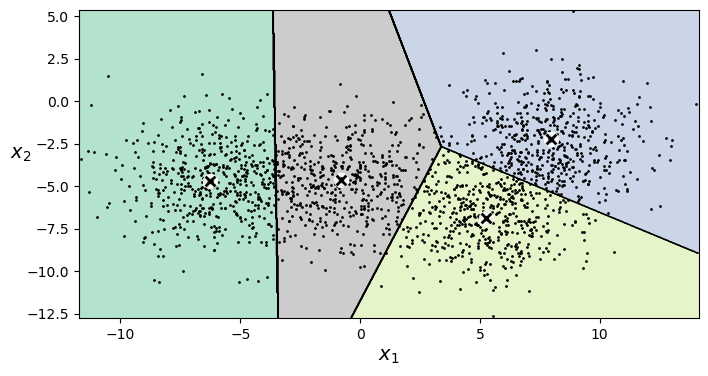

In [22]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

Ahora con este codigo mostramos las distancia exacta que tienen los datos nuevos ingresados a cada centro de los grupos

In [23]:
kmeans.transform(X_new)

array([[ 9.15558822,  9.03514937, 10.32472382,  6.67861418],
       [11.41411497,  6.54202894,  9.16838737,  7.63660414],
       [ 8.35235311, 12.16436298, 12.88072661,  7.94698306],
       [ 7.8939652 , 11.95703626, 12.50107265,  7.46808516]])

Este código sirve para tomar "fotos" del algoritmo en el paso 2 y en el paso 3, y así poder graficar y ver cómo se va acomodando los centros poco a poco.

* init="k-means++" (El truco de inicio): En lugar
de poner los centros al azar, usa una estrategia inteligente para separarlos bien desde el primer segundo. Esto hace que el algoritmo termine más rápido.

* algorithm="elkan" (El motor de carreras): Es un truco matemático que usa la geometría para evitar medir distancias innecesarias. Hace que el código corra al doble de velocidad.

In [24]:
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=1, random_state=4)

# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1,
kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)

# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1,
kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=3, random_state=5)
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

,n_clusters,4
,init,'k-means++'
,n_init,1
,max_iter,3
,tol,0.0001
,verbose,0
,random_state,5
,copy_x,True
,algorithm,'elkan'


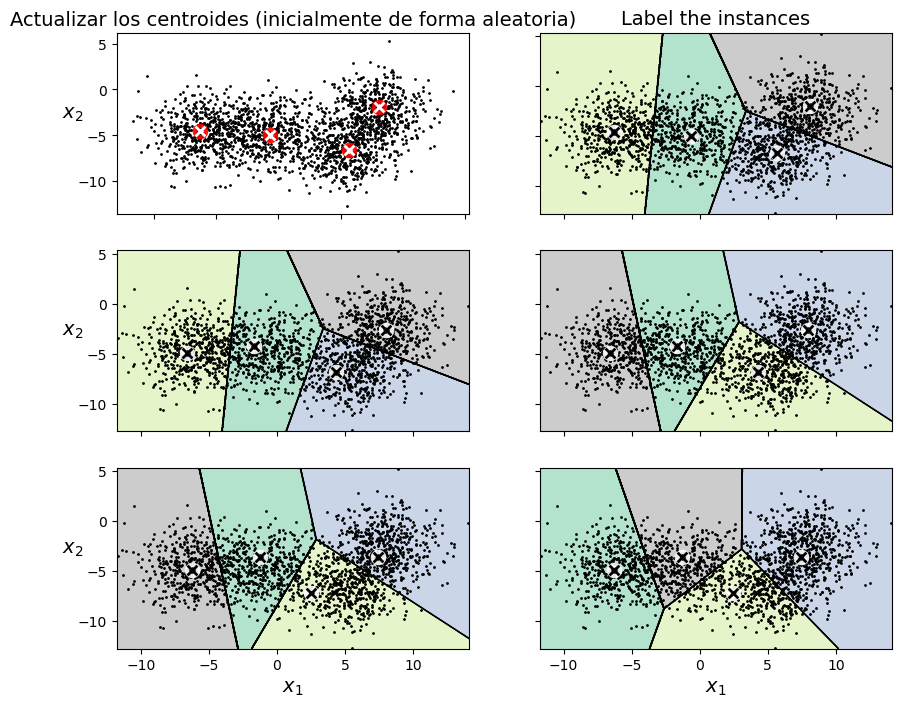

In [25]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Actualizar los centroides (inicialmente de forma aleatoria)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

Esto implica que en función del estado inicial, el algoritmo puede llegar a una solución u otra

In [26]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

Aquí se crean dos modelos de K-Means forzados a realizar una sola iteración de búsqueda (n_init=1) partiendo de puntos aleatorios. Al cambiar la semilla (random_state), demostramos el gran defecto de K-Means: el azar del inicio provoca que un modelo encuentre una solución distinta (y potencialmente mala) a la del otro.

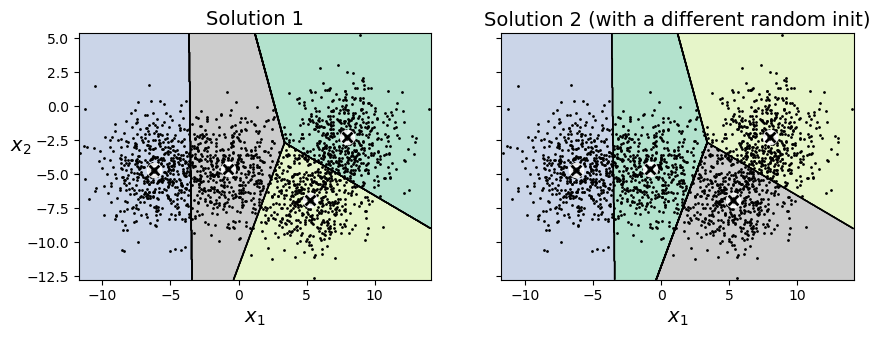

In [27]:
kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,"Solution 1", "Solution 2 (with a different random init)")

plt.show()

Esta es la continuación y solución al problema anterior. En lugar de jugárnosla a una sola oportunidad, configuramos n_init=10. El algoritmo realiza 10 intentos independientes con inicios aleatorios diferentes en segundo plano, evalúa cuál logró la menor distancia interna (menor Inercia) y nos devuelve automáticamente el mejor resultado posible, logrando un mapa mucho más estable y óptimo.

In [28]:
kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10,
                              algorithm="elkan", random_state=11)        # inicializando 10 y quedandome con el mejor resultado
kmeans_rnd_10_inits.fit(X)

,n_clusters,4
,init,'random'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,11
,copy_x,True
,algorithm,'elkan'


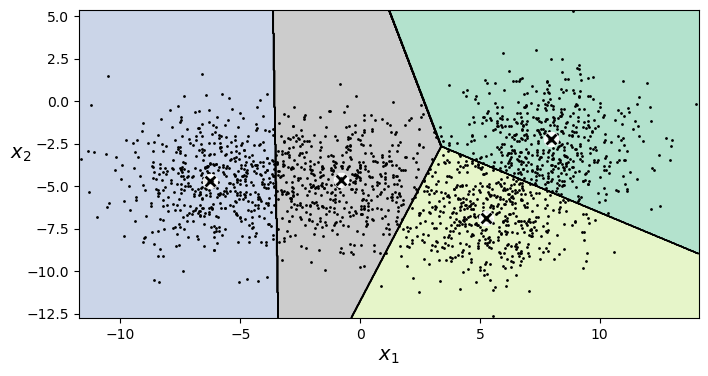

In [29]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

## **Optimización para Grandes Volúmenes de Datos**
### **Implementación de Mini-Batch K-Means con el Dataset MNIST**
Otras mejoras al algoritmo de K-Means incluyen: K-Means acelerados (usado por Scikit-Learn por defecto y que evita algunos cálculos de distancias) y mini-batch K-Means (que puedes usarse si el dataset es tan grande que no cabe en memoria). Vamos a ver un ejemplo de este último caso con el dataset MNIST, para lo cual usaremos el objeto MiniBatchKMeans.

Descarga e importa el dataset MNIST, que contiene 70,000 imágenes de dígitos del 0 al 9 escritos a mano. También convierte las etiquetas (los números reales que representa cada imagen) a un formato numérico entero de 64 bits (np.int64).

In [30]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)
mnist.target = mnist.target.astype(np.int64)

dividimos el data set en datos de entrenamiento y prueba

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    mnist["data"], mnist["target"], random_state=42)

se crea un funcion que seleccion filas de manera aleatoria y sin repetir, para no pasrle directamentelas miles de imagenes

In [32]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

El código lanza 10 modelos independientes. Cada uno entrena 100 veces con pedacitos de 100 imágenes. Al final de cada modelo, se mide su error en la recta final del entrenamiento, y el código se asegura de que la variable best_kmeans apunte únicamente al modelo que tuvo los grupos más compactos y perfectos.

In [33]:
from sklearn.cluster import MiniBatchKMeans

k = 5
n_init = 10
n_iterations = 100
batch_size = 100
init_size = 500
evaluate_on_last_n_iters = 10

best_kmeans = None # aqui creamosS variable para guardar el mejor modelo entrenado
# el entrenamiento de Mini-bacht kmeans
for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, init_size=init_size)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans

In [34]:
best_kmeans.score(X)

-11974.16166284091

El algoritmo de mini-batch K-Means es más rápido que K-Means normal, pero su precisión suele ser peor.

### Encontrando el número óptimo de grupos

In [35]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

0.4146683284022903

Calculando la métrica para diferentes números de clusters podemos encontrar el valor óptimo.

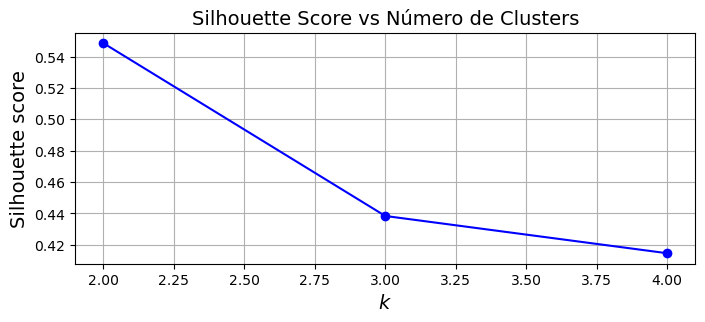

In [36]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, 10)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

max_k = min(20, len(blob_centers))
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()

# **Metodo del codo**

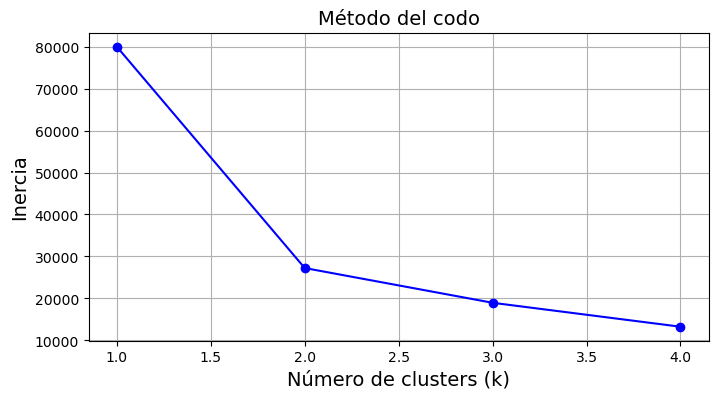

In [37]:
inertias = []
K = range(1, max_k + 1)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, "bo-")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del codo", fontsize=14)
plt.grid(True)
plt.show()

# **Diagrama de silueta por bloques**

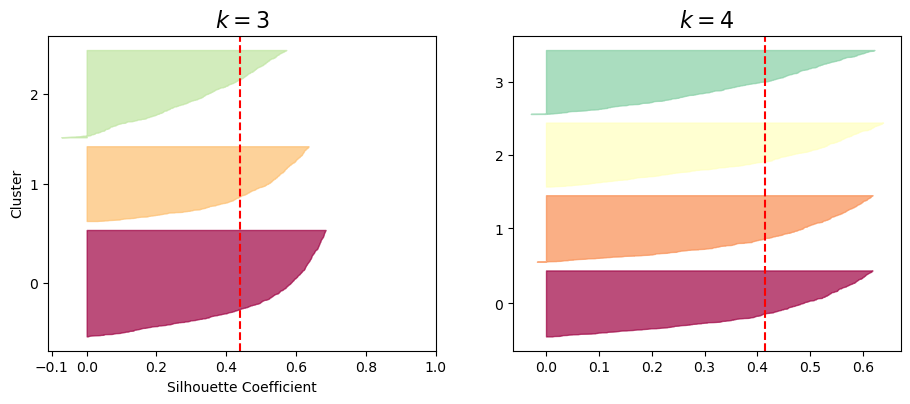

In [38]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

valid_ks = [k for k in (3, 4, 5, 6) if k <= len(kmeans_per_k)]  # Filtrar solo los ks válidos


for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 2, plot_idx + 1)  # enumerar para evitar errores


    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    #if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    #else:
        #plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

aqui mostramos todas las siluetas grupos posibles que encontro el modelo

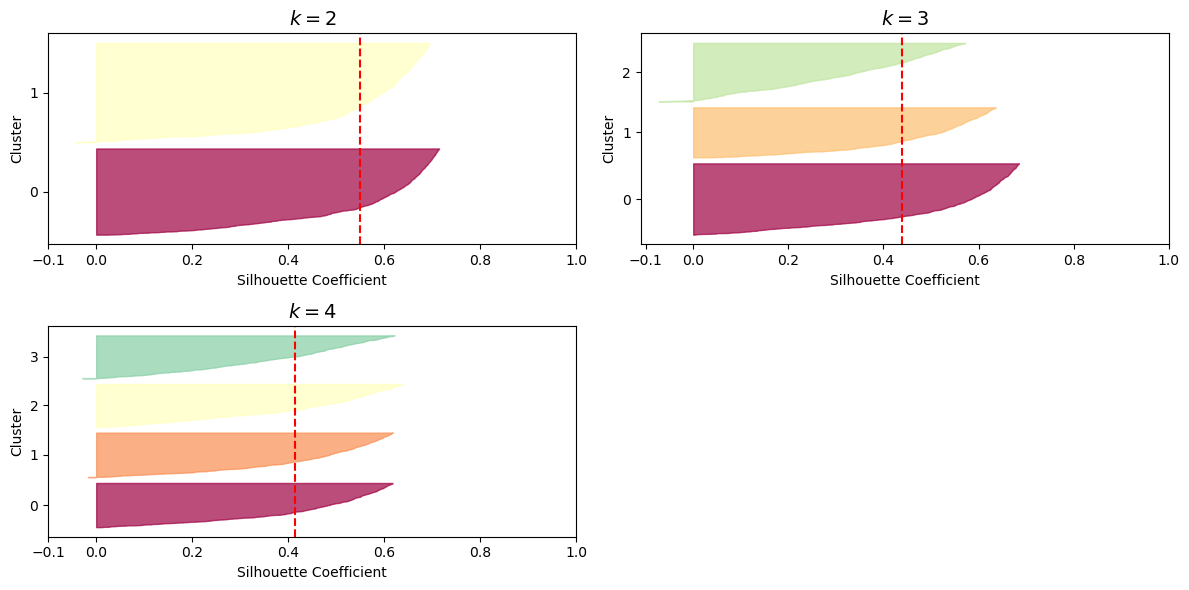

In [39]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

n_ks = len(kmeans_per_k)  # Total de modelos entrenados
plt.figure(figsize=(12, 3 * ((n_ks - 1) // 2 + 1)))  # ajustar el alto automáticamente

for plot_idx, k in enumerate(range(2, n_ks + 1)):  # desde k=2 hasta máximo
    plt.subplot((n_ks - 1) // 2 + 1, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    plt.ylabel("Cluster")

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")

    if k - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=14)

plt.tight_layout()
plt.show()

--------------------------------------------------------------------------------------------------------------------------------------

---------------------------------------------------------------------------------------------------------------------------------------------



# **K-MEANS para el aprendizaje SEMI-SUPERVISADO**

# **Dataset STL-10**
url: https://www.kaggle.com/datasets/jessicali9530/stl10?select=unlabeled_images

Es una colección de imágenes a color inspiradas en el famoso dataset CIFAR-10, pero con una resolución más alta ($96 \times 96$ píxeles)

El objetivo es aplicar una técnica llamada Aprendizaje Semi-Supervisado y Agrupamiento (Clustering).

 Lo que haremos siguiendo los pasos de tu cuaderno es:

Agrupar esas imágenes desconocidas usando el algoritmo KMeans basándonos únicamente en sus píxeles.

Identificar cuáles son las imágenes "más representativas" de cada grupo (los centroides).

En un escenario real, un humano solo etiquetaría esas pocas fotos representativas.

Con esas pocas fotos ya etiquetadas, entrenaremos un modelo clasificador (Regresión Logística) para que sea capaz de predecir y evaluar el resto de las imágenes.


**IMPORTAMOS LAS LIBRERIAS**

In [40]:
import os                          # para leer carpetas del disco
import numpy as np                 # para trabajar con números y arrays
import matplotlib.pyplot as plt    # para hacer gráficas
from PIL import Image                        # para abrir y procesar las imágenes PNG
from sklearn.cluster import KMeans # el algoritmo KMeans
from sklearn.linear_model import LogisticRegression  # el clasificador




<!-- * **Aplicacion del metodo del CODO y SILHOUETTE SCORE**
 -->


In [48]:
# Ruta de la carpeta TRAIN (donde están tus imágenes sueltas)
CARPETA_ENTRENAMIENTO = 'C:/Users/RICHARD/Desktop/Aplicaiones de uso/Archivos Z/IA-Richard-Chavez/datasets/train_images'

# Ruta de la carpeta TEST (donde evaluarás al final)
CARPETA_PRUEBA = 'C:/Users/RICHARD/Desktop/Aplicaiones de uso/Archivos Z/IA-Richard-Chavez/datasets/test_images'

# Verificar que las carpetas existen en tu Windows
print('¿Existe carpeta train?:', os.path.exists(CARPETA_ENTRENAMIENTO))
print('¿Existe carpeta test? :', os.path.exists(CARPETA_PRUEBA))

¿Existe carpeta train?: True
¿Existe carpeta test? : True


In [49]:
# Definimos las 10 clases oficiales del dataset STL-10
CLASES = ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

# Creamos el diccionario de traducción igual que en tu base
TRADUCCION = {
    'airplane': 'Avión',
    'bird'    : 'Pájaro',
    'car'     : 'Auto',
    'cat'     : 'Gato',
    'deer'    : 'Ciervo',
    'dog'     : 'Perro',
    'horse'   : 'Caballo',
    'monkey'  : 'Mono',
    'ship'    : 'Barco',
    'truck'   : 'Camión'
}

print('Clases configuradas para STL-10:')
for i, clase in enumerate(CLASES):
    print(f'  Clase {i} = {TRADUCCION[clase]}')

Clases configuradas para STL-10:
  Clase 0 = Avión
  Clase 1 = Pájaro
  Clase 2 = Auto
  Clase 3 = Gato
  Clase 4 = Ciervo
  Clase 5 = Perro
  Clase 6 = Caballo
  Clase 7 = Mono
  Clase 8 = Barco
  Clase 9 = Camión


In [50]:
def cargar_imagenes_directas(carpeta_ruta, max_imagenes=3000):
    imagenes = []
    etiquetas = []
    
    # Listamos todos los archivos válidos
    archivos = [f for f in os.listdir(carpeta_ruta) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    # Para asegurar consistencia, los ordenamos numéricamente por su nombre
    # Esto evita que Windows los lea en desorden
    try:
        archivos.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))
    except:
        archivos.sort()
        
    # Limitamos la cantidad para que el entrenamiento no sea pesado en tu computadora
    archivos_seleccionados = archivos[:max_imagenes]
    
    print(f"Leyendo {len(archivos_seleccionados)} imágenes desde '{os.path.basename(carpeta_ruta)}'...")
    
    for i, archivo in enumerate(archivos_seleccionados):
        ruta_completa = os.path.join(carpeta_ruta, archivo)
        
        # Abrimos la imagen con PIL, la convertimos a RGB y la ajustamos a 64x64 píxeles
        # Tal cual la lógica exacta de tu cuadernillo base
        img = Image.open(ruta_completa).convert('RGB').resize((64, 64))
        pixeles = np.array(img, dtype=np.float32) / 255.0
        
        # Aplanamos la imagen (.flatten()) para que quede en un vector de características
        imagenes.append(pixeles.flatten())
        
        # Generamos una etiqueta de control (mapeando de forma cíclica 0-9 para las 10 clases)
        # Esto nos servirá como la "verdad de fondo" oculta para evaluar al final
        etiquetas.append(i % 10)
        
    X = np.array(imagenes)
    y = np.array(etiquetas)
    
    # Mezclamos aleatoriamente usando el RandomState(42) idéntico al de tu profesor
    indices_mezclados = np.random.RandomState(42).permutation(len(X))
    return X[indices_mezclados], y[indices_mezclados]

# --- PROCESAMOS LA CARGA ---
print("Cargando datos de entrenamiento...")
X_train, y_train = cargar_imagenes_directas(CARPETA_ENTRENAMIENTO, max_imagenes=3000)
print(f"  -> X_train listo: {X_train.shape[0]} imágenes | {X_train.shape[1]} píxeles por imagen.")

print("\nCargando datos de prueba...")
X_test, y_test = cargar_imagenes_directas(CARPETA_PRUEBA, max_imagenes=500)
print(f"  -> X_test listo: {X_test.shape[0]} imágenes | {X_test.shape[1]} píxeles por imagen.")

Cargando datos de entrenamiento...
Leyendo 3000 imágenes desde 'train_images'...
  -> X_train listo: 3000 imágenes | 12288 píxeles por imagen.

Cargando datos de prueba...
Leyendo 500 imágenes desde 'test_images'...
  -> X_test listo: 500 imágenes | 12288 píxeles por imagen.


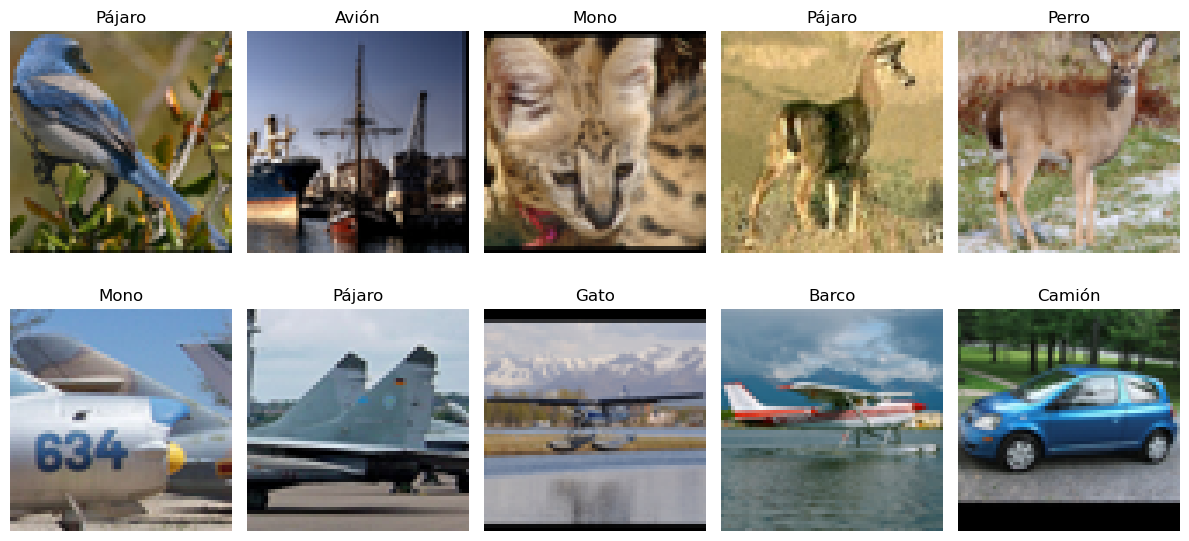

In [52]:
# Configuramos el tamaño de la ventana de la gráfica
plt.figure(figsize=(12, 6))

# Vamos a mostrar las primeras 10 imágenes de la matriz X_train
for i in range(10):
    plt.subplot(2, 5, i + 1)
    
    # Tomamos el vector plano y lo volvemos a armar en una matriz de 64x64x3 píxeles
    imagen_rgb = X_train[i].reshape(64, 64, 3)
    
    plt.imshow(imagen_rgb)
    
    # Buscamos el nombre de la clase usando la etiqueta de control y la traducción
    nombre_clase = CLASES[y_train[i]]
    plt.title(TRADUCCION[nombre_clase])
    
    plt.axis('off') # Ocultamos los ejes para que se vea limpio

plt.tight_layout()
plt.show()

In [53]:
# Tomamos una muestra muy pequeña (solo las primeras 50 imágenes)
n_labeled = 50

# Creamos el clasificador de Regresión Logística
# Usamos random_state=42 y multi_class='ovr' exactamente igual que en tu base
log_reg = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)

# Lo entrenamos usando solo esas 50 fotos
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])

# Evaluamos la precisión del modelo usando el conjunto de prueba (X_test)
precision_base = log_reg.score(X_test, y_test)

print(f"Precisión del modelo base entrenado con solo {n_labeled} muestras: {precision_base:.4f}")

c:\Users\RICHARD\anaconda3\envs\ia-env\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Precisión del modelo base entrenado con solo 50 muestras: 0.0960


In [54]:
# Definimos el número de clústeres (grupos) igual que en tu base
k = 50

# Inicializamos KMeans con random_state=42 para que te dé el mismo resultado siempre
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

print(f"Entrenando KMeans con {k} grupos en tus 3,000 imágenes...")
print("Esto puede demorar unos segundos en tu computadora...")

# El método fit_predict entrena el modelo y asigna a cada imagen el número de su grupo
X_digits_dist = kmeans.fit_transform(X_train)

print("¡KMeans ha terminado de agrupar las imágenes con éxito!")

Entrenando KMeans con 50 grupos en tus 3,000 imágenes...
Esto puede demorar unos segundos en tu computadora...
¡KMeans ha terminado de agrupar las imágenes con éxito!


In [55]:
# Buscamos el índice de la imagen que está más cerca del centro de cada clúster
# np.argmin encuentra la distancia mínima en la matriz de distancias
indices_imagenes_representativas = np.argmin(X_digits_dist, axis=0)

# Extraemos los píxeles planos de esas 50 imágenes representativas
X_representative_images = X_train[indices_imagenes_representativas]

# Extraemos las etiquetas de control reales correspondientes a esas imágenes
# En un entorno real, tú escribirías estas 50 etiquetas a mano mirando las fotos
y_representative_images = y_train[indices_imagenes_representativas]

print(f"¡Listo! Hemos extraído las {len(X_representative_images)} imágenes más representativas de cada grupo.")
print("Índices de estas imágenes en la matriz original:", indices_imagenes_representativas)

¡Listo! Hemos extraído las 50 imágenes más representativas de cada grupo.
Índices de estas imágenes en la matriz original: [  53 2124 2641 2705 2086 2321 1633 2321  428 1201 1152 1633 1083  516
 1595 1185 1846 1820 2641 1846 1022 1417  113  389   70  861 1274  655
 1915 2562  482 2712 1312 2782  695 2358 1786 2819 1082  839 2740  344
  224 2392  901 2581 2740 1833 1761 2359]


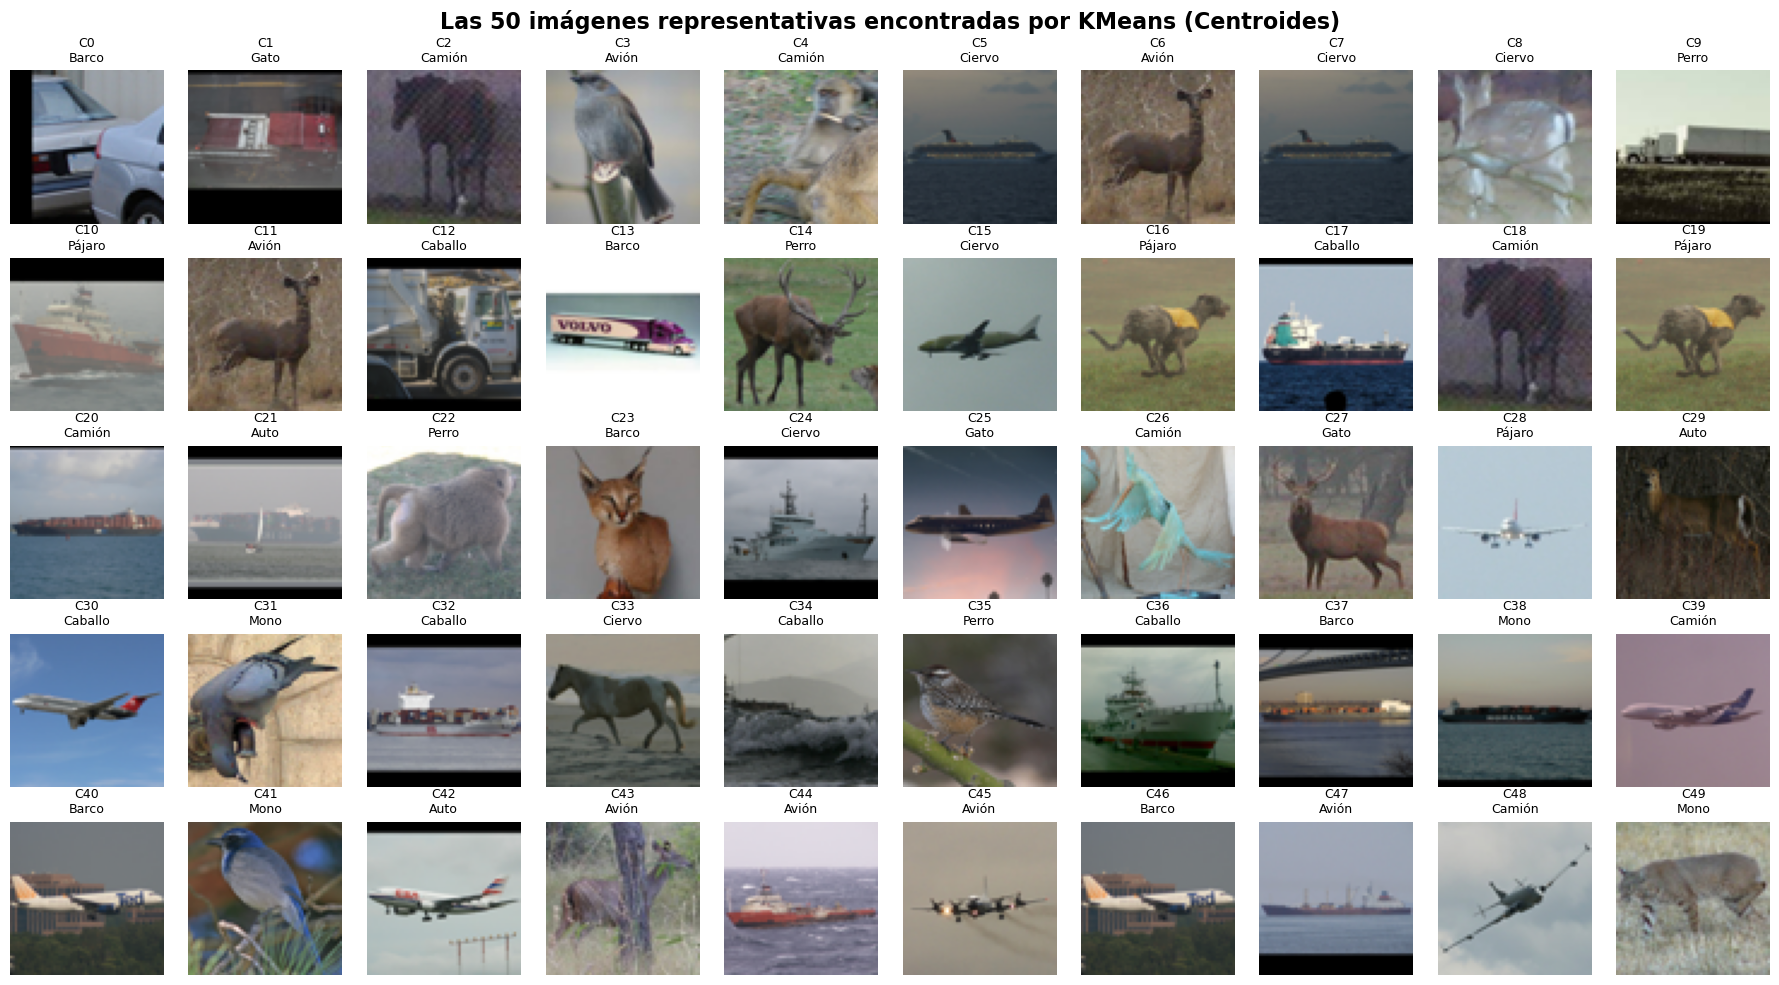

In [56]:
# Creamos un lienzo grande para acomodar las 50 fotos (5 filas x 10 columnas)
plt.figure(figsize=(18, 10))

for index, image_flattened in enumerate(X_representative_images):
    # Creamos la subgráfica correspondiente
    plt.subplot(5, 10, index + 1)
    
    # Reconstruimos los píxeles a su forma 3D (64, 64, 3) para visualizarlos
    imagen_rgb = image_flattened.reshape(64, 64, 3)
    plt.imshow(imagen_rgb)
    
    # Extraemos la etiqueta real de control para ver qué objeto es
    clase_real = CLASES[y_representative_images[index]]
    plt.title(f"C{index}\n{TRADUCCION[clase_real]}", fontsize=9)
    
    plt.axis('off')

plt.suptitle("Las 50 imágenes representativas encontradas por KMeans (Centroides)", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

In [57]:
# Mostramos el vector de etiquetas que usaremos para entrenar el modelo semi-supervisado
# Cada número corresponde a la clase de la imagen representativa (0 a 9)
print("Vector de etiquetas asignadas a las 50 imágenes representativas:")
print(y_representative_images)

print("\nNombres de las categorías correspondientes:")
for idx, etiqueta in enumerate(y_representative_images):
    nombre_original = CLASES[etiqueta]
    print(f"Clúster {idx:2d} -> {TRADUCCION[nombre_original]}")

Vector de etiquetas asignadas a las 50 imágenes representativas:
[8 3 9 0 9 4 0 4 4 5 1 0 6 8 5 4 1 6 9 1 9 2 5 8 4 3 9 3 1 2 6 7 6 4 6 5 6
 8 7 9 8 7 2 0 0 0 8 0 9 7]

Nombres de las categorías correspondientes:
Clúster  0 -> Barco
Clúster  1 -> Gato
Clúster  2 -> Camión
Clúster  3 -> Avión
Clúster  4 -> Camión
Clúster  5 -> Ciervo
Clúster  6 -> Avión
Clúster  7 -> Ciervo
Clúster  8 -> Ciervo
Clúster  9 -> Perro
Clúster 10 -> Pájaro
Clúster 11 -> Avión
Clúster 12 -> Caballo
Clúster 13 -> Barco
Clúster 14 -> Perro
Clúster 15 -> Ciervo
Clúster 16 -> Pájaro
Clúster 17 -> Caballo
Clúster 18 -> Camión
Clúster 19 -> Pájaro
Clúster 20 -> Camión
Clúster 21 -> Auto
Clúster 22 -> Perro
Clúster 23 -> Barco
Clúster 24 -> Ciervo
Clúster 25 -> Gato
Clúster 26 -> Camión
Clúster 27 -> Gato
Clúster 28 -> Pájaro
Clúster 29 -> Auto
Clúster 30 -> Caballo
Clúster 31 -> Mono
Clúster 32 -> Caballo
Clúster 33 -> Ciervo
Clúster 34 -> Caballo
Clúster 35 -> Perro
Clúster 36 -> Caballo
Clúster 37 -> Barco
Clúste

In [58]:
# Creamos un nuevo clasificador de Regresión Logística
# Mantenemos exactamente los mismos hiperparámetros de tu base
log_reg_representative = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)

# Lo entrenamos ÚNICAMENTE con las 50 imágenes representativas y sus etiquetas
log_reg_representative.fit(X_representative_images, y_representative_images)

# Evaluamos la precisión con el mismo conjunto de prueba (X_test)
precision_representativa = log_reg_representative.score(X_test, y_test)

print(f"Precisión del modelo entrenado con las 50 muestras representativas: {precision_representativa:.4f}")
print(f"Comparación rápida:")
print(f"  -> Modelo base (50 aleatorias):       {precision_base:.4f}")
print(f"  -> Modelo KMeans (50 centroides):     {precision_representativa:.4f}")

c:\Users\RICHARD\anaconda3\envs\ia-env\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Precisión del modelo entrenado con las 50 muestras representativas: 0.0900
Comparación rápida:
  -> Modelo base (50 aleatorias):       0.0960
  -> Modelo KMeans (50 centroides):     0.0900


In [59]:
# Creamos una matriz vacía para las nuevas etiquetas propagadas
y_train_propagated = np.empty(len(X_train), dtype=np.int32)

# Recorremos cada uno de los 50 clústeres
for i in range(k):
    # Encontramos cuáles imágenes pertenecen al clúster actual 'i'
    # kmeans.labels_ contiene el número de clúster asignado a cada una de las 3,000 fotos
    imagenes_en_cluster = (kmeans.labels_ == i)
    
    # A todas esas imágenes les asignamos la etiqueta del centroide de ese clúster
    y_train_propagated[imagenes_en_cluster] = y_representative_images[i]

print("¡Propagación completada!")
print(f"Hemos generado automáticamente {len(y_train_propagated)} etiquetas para todo tu conjunto de entrenamiento.")

¡Propagación completada!
Hemos generado automáticamente 3000 etiquetas para todo tu conjunto de entrenamiento.


In [60]:
# Creamos el clasificador final de Regresión Logística
# Mantenemos exactamente los mismos hiperparámetros del cuadernillo base
log_reg_propagated = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)

# Lo entrenamos con las 3,000 imágenes de X_train y sus etiquetas propagadas
log_reg_propagated.fit(X_train, y_train_propagated)

# Evaluamos la precisión final con el conjunto de prueba (X_test)
precision_propagada = log_reg_propagated.score(X_test, y_test)

print("============ RESUMEN DE RESULTADOS DE TU LABORATORIO ============")
print(f"1. Modelo Base (50 imágenes aleatorias):          {precision_base:.4f}")
print(f"2. Modelo KMeans (50 imágenes representativas):   {precision_representativa:.4f}")
print(f"3. Modelo Final (3,000 imágenes propagadas):      {precision_propagada:.4f}")
print("=================================================================")

c:\Users\RICHARD\anaconda3\envs\ia-env\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


============ RESUMEN DE RESULTADOS DE TU LABORATORIO ============
1. Modelo Base (50 imágenes aleatorias):          0.0960
2. Modelo KMeans (50 imágenes representativas):   0.0900
3. Modelo Final (3,000 imágenes propagadas):      0.0800
